# Analyse all subsets

The workflow runs one job per `(n_samples, seed)` pair, writing each result to
`output/<n_samples>/<seed>/result.json`. Those pairs are the **subsets** of this
experiment.

Where `2_plot.ipynb` draws a single job in isolation, this notebook reads *every*
subset back in and compares them: how the π estimate scatters across seeds, and
how the error shrinks as the sample size grows. Run it locally after the jobs
have finished (or after `wf.pull(...)` brings the results back from SLURM).

It is read-only over `output/` — safe to re-run as more subsets complete.

## 1. Collect every subset

`jobs.json` is the source of truth for which subsets exist, so we enumerate them
with the same `nb2slurm.Structure` the workflow uses — the analysis can never
drift from the job list. Subsets whose `result.json` isn't there yet are reported
and skipped, so a partial run still analyses fine.

In [1]:
import json
import math
from pathlib import Path
from statistics import mean, pstdev

import matplotlib.pyplot as plt
import nb2slurm

OUTPUT = Path("output")
TRUE_PI = math.pi

# every subset this workflow defines, straight from jobs.json
struct = nb2slurm.Structure.from_json("jobs.json")
paths = struct.paths(OUTPUT)            # {"1000/1": Path("output/1000/1"), ...}

records, missing = [], []
for rel, folder in paths.items():
    n_samples, seed = rel.split("/")
    result_file = folder / "result.json"
    if not result_file.exists():
        missing.append(rel)
        continue
    r = json.loads(result_file.read_text())
    records.append({
        "n_samples": int(n_samples),
        "seed": int(seed),
        "pi": r["pi"],
        "error": abs(r["pi"] - TRUE_PI),
    })

records.sort(key=lambda d: (d["n_samples"], d["seed"]))
print(f"loaded {len(records)} subset(s); {len(missing)} missing")
if missing:
    print("missing (run the workflow for these first):", ", ".join(missing))

loaded 6 subset(s); 0 missing


## 2. One row per subset

The raw table: every `(n_samples, seed)` pair, its π estimate, and the absolute
error against the true value.

In [2]:
print(f"{'n_samples':>10} {'seed':>5} {'pi_est':>10} {'abs_error':>10}")
for d in records:
    print(f"{d['n_samples']:>10} {d['seed']:>5} {d['pi']:>10.5f} {d['error']:>10.5f}")

 n_samples  seed     pi_est  abs_error
      1000     1    3.11200    0.02959
      1000     2    3.12800    0.01359
      1000     3    3.16800    0.02641
   1000000     1    3.14138    0.00021
   1000000     2    3.14092    0.00067
   1000000     3    3.13863    0.00296


## 3. Aggregate across seeds

For each sample size, collapse its seeds into a mean estimate, a spread (the
standard deviation tells you how much the answer wobbles run-to-run) and the mean
absolute error.

In [3]:
by_n = {}
for d in records:
    by_n.setdefault(d["n_samples"], []).append(d)

summary = []
print(f"{'n_samples':>10} {'runs':>5} {'mean_pi':>10} {'std_pi':>10} {'mean_err':>10}")
for n in sorted(by_n):
    rows = by_n[n]
    pis = [r["pi"] for r in rows]
    errs = [r["error"] for r in rows]
    m, s, e = mean(pis), pstdev(pis), mean(errs)
    summary.append({"n_samples": n, "runs": len(rows), "mean_pi": m, "std_pi": s, "mean_err": e})
    print(f"{n:>10} {len(rows):>5} {m:>10.5f} {s:>10.5f} {e:>10.5f}")

 n_samples  runs    mean_pi     std_pi   mean_err
      1000     3    3.13600    0.02355    0.02320
   1000000     3    3.14031    0.00120    0.00128


## 4. π estimate per subset

Each subset as a point, grouped by sample size, against the true value. Larger
sample sizes cluster tightly around π; small ones scatter.

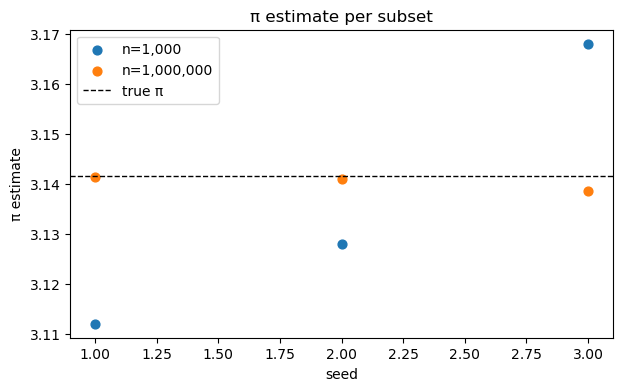

In [4]:
if records:
    fig, ax = plt.subplots(figsize=(7, 4))
    for n in sorted(by_n):
        rows = by_n[n]
        ax.scatter([r["seed"] for r in rows], [r["pi"] for r in rows],
                   label=f"n={n:,}", s=40)
    ax.axhline(TRUE_PI, color="k", ls="--", lw=1, label="true π")
    ax.set_xlabel("seed")
    ax.set_ylabel("π estimate")
    ax.set_title("π estimate per subset")
    ax.legend()
    fig.savefig(OUTPUT / "estimates_by_subset.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("no results yet — run the workflow, then re-run this notebook")

## 5. Convergence across subsets

Monte Carlo error scales like $1/\sqrt{n}$. On log–log axes the mean error should
fall along that reference slope as the sample size grows.

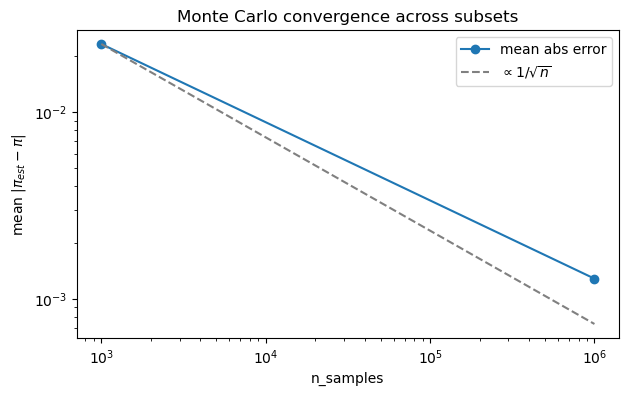

In [5]:
if summary:
    ns = [s["n_samples"] for s in summary]
    errs = [s["mean_err"] for s in summary]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.loglog(ns, errs, "o-", label="mean abs error")
    # reference 1/sqrt(n), anchored at the first point
    ref = [errs[0] * (ns[0] / n) ** 0.5 for n in ns]
    ax.loglog(ns, ref, "--", color="grey", label=r"$\propto 1/\sqrt{n}$")
    ax.set_xlabel("n_samples")
    ax.set_ylabel(r"mean $|\pi_{est} - \pi|$")
    ax.set_title("Monte Carlo convergence across subsets")
    ax.legend()
    fig.savefig(OUTPUT / "convergence.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("need at least one result to plot convergence")

## What this shows

* Each `(n_samples, seed)` subset is loaded straight from its `output/` folder, so
  this notebook is a pure consumer of the workflow's results.
* Across seeds, more samples → less scatter and smaller error.
* The error follows the classic $1/\sqrt{n}$ Monte Carlo slope.

Re-run any time more subsets finish; missing ones are simply skipped. The two
summary figures are written to `output/estimates_by_subset.png` and
`output/convergence.png`.